## Taleb on Cochrane Study (Nina Teicholz)

Firstly, I tried to replicate Taleb's fit using the lognormal
parameters that he has obtained.

However, I could not actually get the correct risk ratios?
Did I miss something in my calculations?

In [15]:
from scipy.optimize import fsolve
import math
import numpy as np
from scipy.stats import lognorm
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure as fig

import seaborn as sns

sns.set_theme()

fig(figsize=(10, 10), dpi=600)

# Values from Taleb using Mathematica.
lm  = -0.188439
ls  = 0.0858363

x = np.linspace(lognorm.ppf(0.001, ls, lm), lognorm.ppf(0.999, ls, lm) , 100)
print("x-value of 0.025 percentile:\t", lognorm.ppf(0.025, ls, lm))
print("x-value of 0.975 percentile:\t", lognorm.ppf(0.975, ls, lm))

print("CDF for more than 1:\t\t", lognorm.cdf(1, ls, lm))
print("Odd's ratio:\t\t\t", lognorm.cdf(1, ls, lm)/lognorm.sf(1, ls, lm))

# section = np.arange(1, 1.15, 1/1000.)
# plt.fill_between(section,lognorm.pdf(section,ls,lm))
# plt.plot(x,lognorm.pdf(x,ls,lm),'k-', lw = 3, alpha=0.6, label='lognorm pdf')

x-value of 0.025 percentile:	 0.6567153069120867
x-value of 0.975 percentile:	 0.9947768835629294
CDF for more than 1:		 0.9778519615323802
Odd's ratio:			 44.150725264541606


<Figure size 6000x6000 with 0 Axes>

## My fit

Did not get Nassim Taleb's fit for the distribution, but similar results for odds ratios.

In [16]:
from scipy.optimize import fsolve
import math
import numpy as np
from scipy.stats import norm
from scipy.stats import lognorm
from scipy.stats import gamma
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure as fig
import seaborn as sns

sns.set()


def problem_statement(comp_str, out_str):
    comp_lbl = "Comparison basis: "
    out_lbl = "Outcome/subgroup: "
    print(comp_lbl + comp_str + '\n' + ('-' * (len(comp_lbl)+len(comp_str))))
    print(out_lbl + out_str + '\n' + ('-' * (len(out_lbl)+len(out_str))))
    fig(figsize=(10, 10), dpi=300)


def lognorm_analysis(fx1, fx2, cix1=0.025, cix2=0.975):

    def lognorm_equations(p):
        m, s = p
        f1 = lognorm.ppf(cix1, s, m) - fx1
        f2 = lognorm.ppf(cix2, s, m) - fx2
        return f1, f2

    m, s = fsolve(lognorm_equations, (1, 1))
    x = np.linspace(lognorm.ppf(0.001, s, m), lognorm.ppf(0.999, s, m), 200)

    print("Lognormal mean:\t\t\t", m)
    print("Lognormal standard deviation:\t", s)
    print("x-value of", cix1 * 100, "percentile:\t", lognorm.ppf(cix1, s, m))
    print("x-value of", cix2 * 100, "percentile:\t", lognorm.ppf(cix2, s, m))
    print("CDF for more than 1:\t\t", lognorm.cdf(1, s, m))
    print("Odd's ratio:\t\t\t", lognorm.cdf(1, s, m)/lognorm.sf(1, s, m))
    print()
    a = np.arange(1, lognorm.ppf(0.999, s, m), 1/1000.)
    plt.plot(x, lognorm.pdf(x, s, m), 'r-', lw=2,
             alpha=0.7, label='lognorm pdf')
    plt.fill_between(a, lognorm.pdf(a, s, m), color='pink')
    plt.legend()


def norm_analysis(fx1, fx2, cix1=0.025, cix2=0.975):

    def norm_equations(p):
        m, s = p
        f1 = norm.ppf(cix1, s, m) - fx1
        f2 = norm.ppf(cix2, s, m) - fx2
        return f1, f2

    m, s = fsolve(norm_equations, (1, 1))
    x = np.linspace(norm.ppf(0.001, s, m), norm.ppf(0.999, s, m), 200)

    print("Normal mean:\t\t\t", m)
    print("Normal standard deviation:\t", s)
    print("x-value of", cix1 * 100, "percentile:\t", norm.ppf(cix1, s, m))
    print("x-value of", cix2 * 100, "percentile:\t", norm.ppf(cix2, s, m))
    print("CDF for more than 1:\t\t", norm.cdf(1, s, m))
    print("Odd's ratio:\t\t\t", norm.cdf(1, s, m)/norm.sf(1, s, m))
    print()
    a = np.arange(1, norm.ppf(0.999, s, m), 1/1000.)
    plt.plot(x, norm.pdf(x, s, m), 'b-', lw=2, alpha=0.7, label='norm pdf')
    plt.fill_between(a, norm.pdf(a, s, m), color='pink')
    plt.legend()


def gamma_analysis(fx1, fx2, cix1=0.025, cix2=0.975):

    def gamma_equations(p):
        k, t = p
        f1 = gamma.ppf(cix1, k, scale=1/t) - fx1
        f2 = gamma.ppf(cix2, k, scale=1/t) - fx2
        return f1, f2

    k, t = fsolve(gamma_equations, (1, 1))
    x = np.linspace(gamma.ppf(0.001, k, scale=1/t),
                    gamma.ppf(0.999, k, scale=1/t), 200)

    print("Gamma shape:\t\t\t", k)
    print("Gamma scale:\t\t\t", t)
    print("x-value of", cix1 * 100, "percentile:\t",
          gamma.ppf(cix1, k, scale=1/t))
    print("x-value of", cix2 * 100, "percentile:\t",
          gamma.ppf(cix2, k, scale=1/t))
    print("CDF for more than 1:\t\t", gamma.cdf(1, k, scale=1/t))
    print("Odd's ratio:\t\t\t", gamma.cdf(
        1, k, scale=1/t)/gamma.sf(1, k, scale=1/t))
    print()
    a = np.arange(1, gamma.ppf(0.999, k, scale=1/t), 1/1000.)
    plt.plot(x, gamma.pdf(x, k, scale=1/t), 'k-',
             lw=2, alpha=0.7, label='gamma pdf')
    plt.fill_between(a, gamma.pdf(a, k, scale=1/t), color='pink')
    plt.legend()


def main(fx1, fx2, comp_str, out_str):
    problem_statement(comp_str, out_str)
    lognorm_analysis(fx1, fx2)
    norm_analysis(fx1, fx2)
    gamma_analysis(fx1, fx2)


Comparison basis: Saturated fat
-------------------------------
Outcome/subgroup: Cardiovascular events
---------------------------------------
Lognormal mean:			 -0.16975244490784652
Lognormal standard deviation:	 0.07119858069207208
x-value of 2.5 percentile:	 0.7000000000004614
x-value of 97.5 percentile:	 0.9800000000024098
CDF for more than 1:		 0.9861737268993873
Odd's ratio:			 71.32607028105691

Normal mean:			 0.07142988396945156
Normal standard deviation:	 0.84
x-value of 2.5 percentile:	 0.7
x-value of 97.5 percentile:	 0.98
CDF for more than 1:		 0.9874532024208621
Odd's ratio:			 78.70161259816184

Gamma shape:			 136.21480417054704
Gamma scale:			 163.2874474438807
x-value of 2.5 percentile:	 0.699999999997821
x-value of 97.5 percentile:	 0.9799999999967647
CDF for more than 1:		 0.9864387115641781
Odd's ratio:			 72.7393061678799



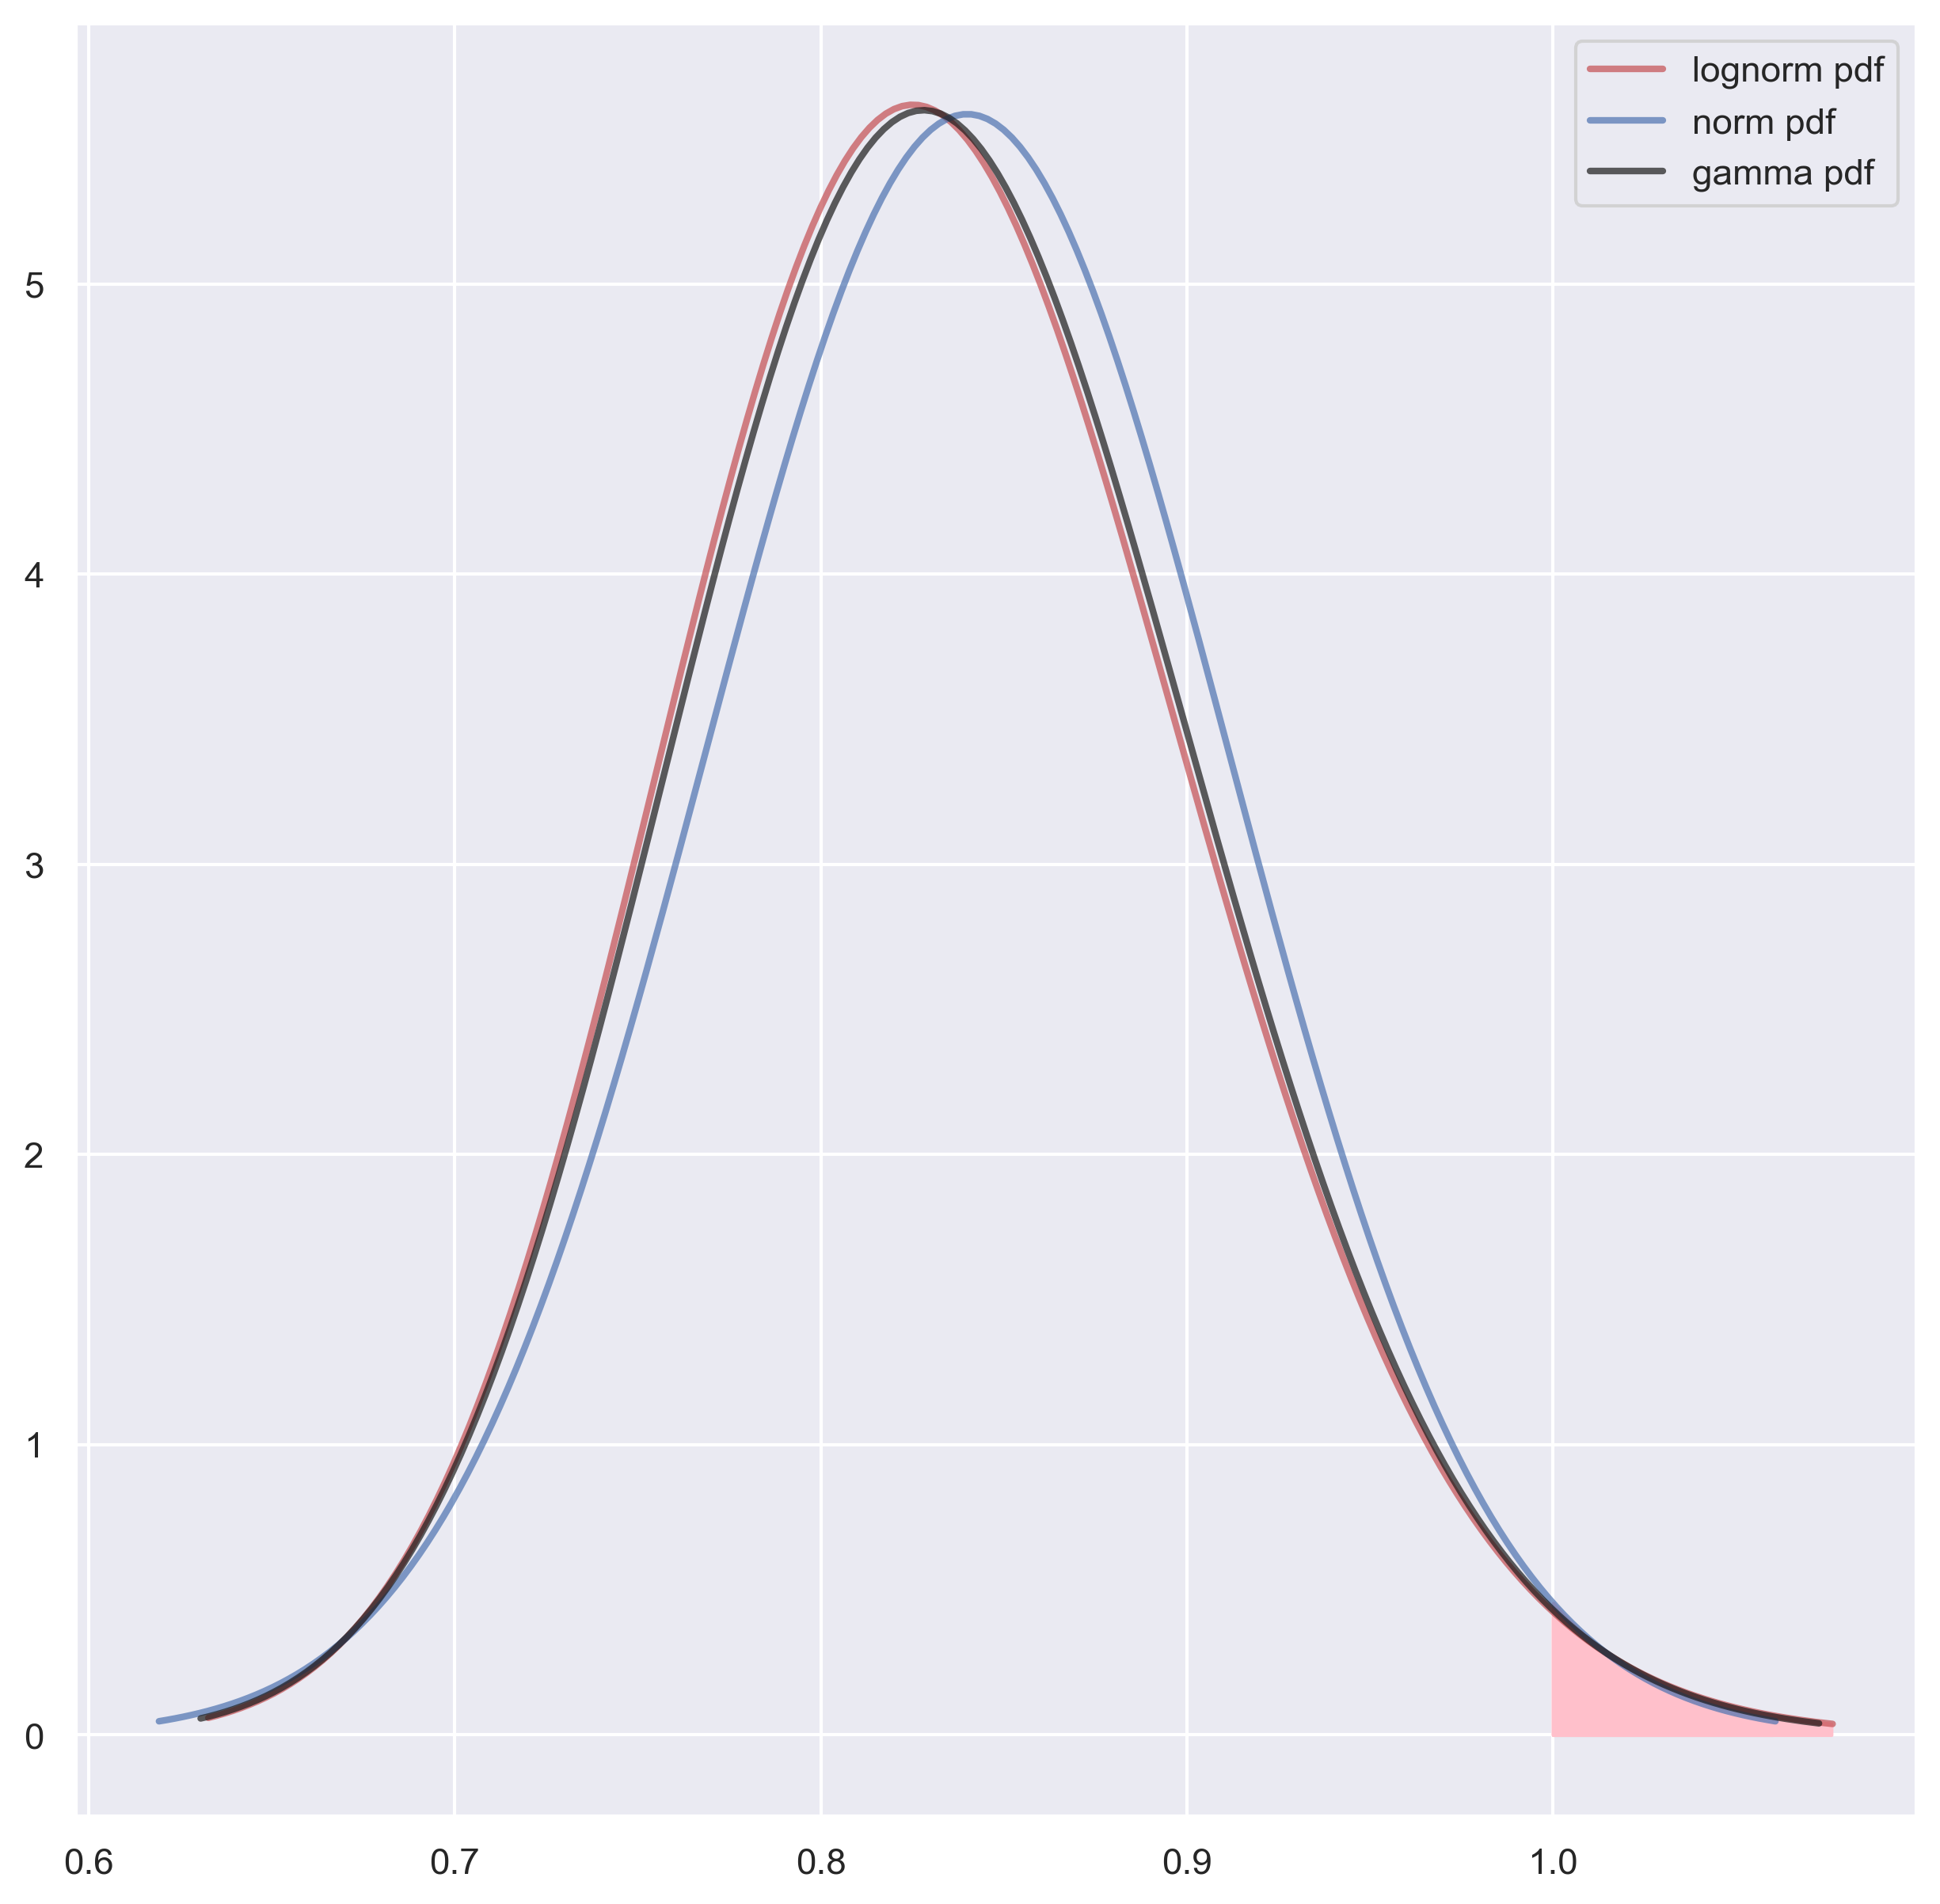

In [17]:
main(0.7, 0.98, 'Saturated fat', 'Cardiovascular events')


Comparison basis: Saturated fat
-------------------------------
Outcome/subgroup: General mortality
-----------------------------------
Lognormal mean:			 -0.03711027337314412
Lognormal standard deviation:	 0.033140566093353474
x-value of 2.5 percentile:	 0.9000000000000006
x-value of 97.5 percentile:	 1.030000000000002
CDF for more than 1:		 0.8642263642841072
Odd's ratio:			 6.365200134233026

Normal mean:			 0.033163874700102534
Normal standard deviation:	 0.9650000000000001
x-value of 2.5 percentile:	 0.9
x-value of 97.5 percentile:	 1.0300000000000002
CDF for more than 1:		 0.8543708389857402
Odd's ratio:			 5.866756582509469

Gamma shape:			 844.6182863867637
Gamma scale:			 876.2335322954253
x-value of 2.5 percentile:	 0.9000000000001114
x-value of 97.5 percentile:	 1.0300000000001448
CDF for more than 1:		 0.8612590730494966
Odd's ratio:			 6.207678527020048



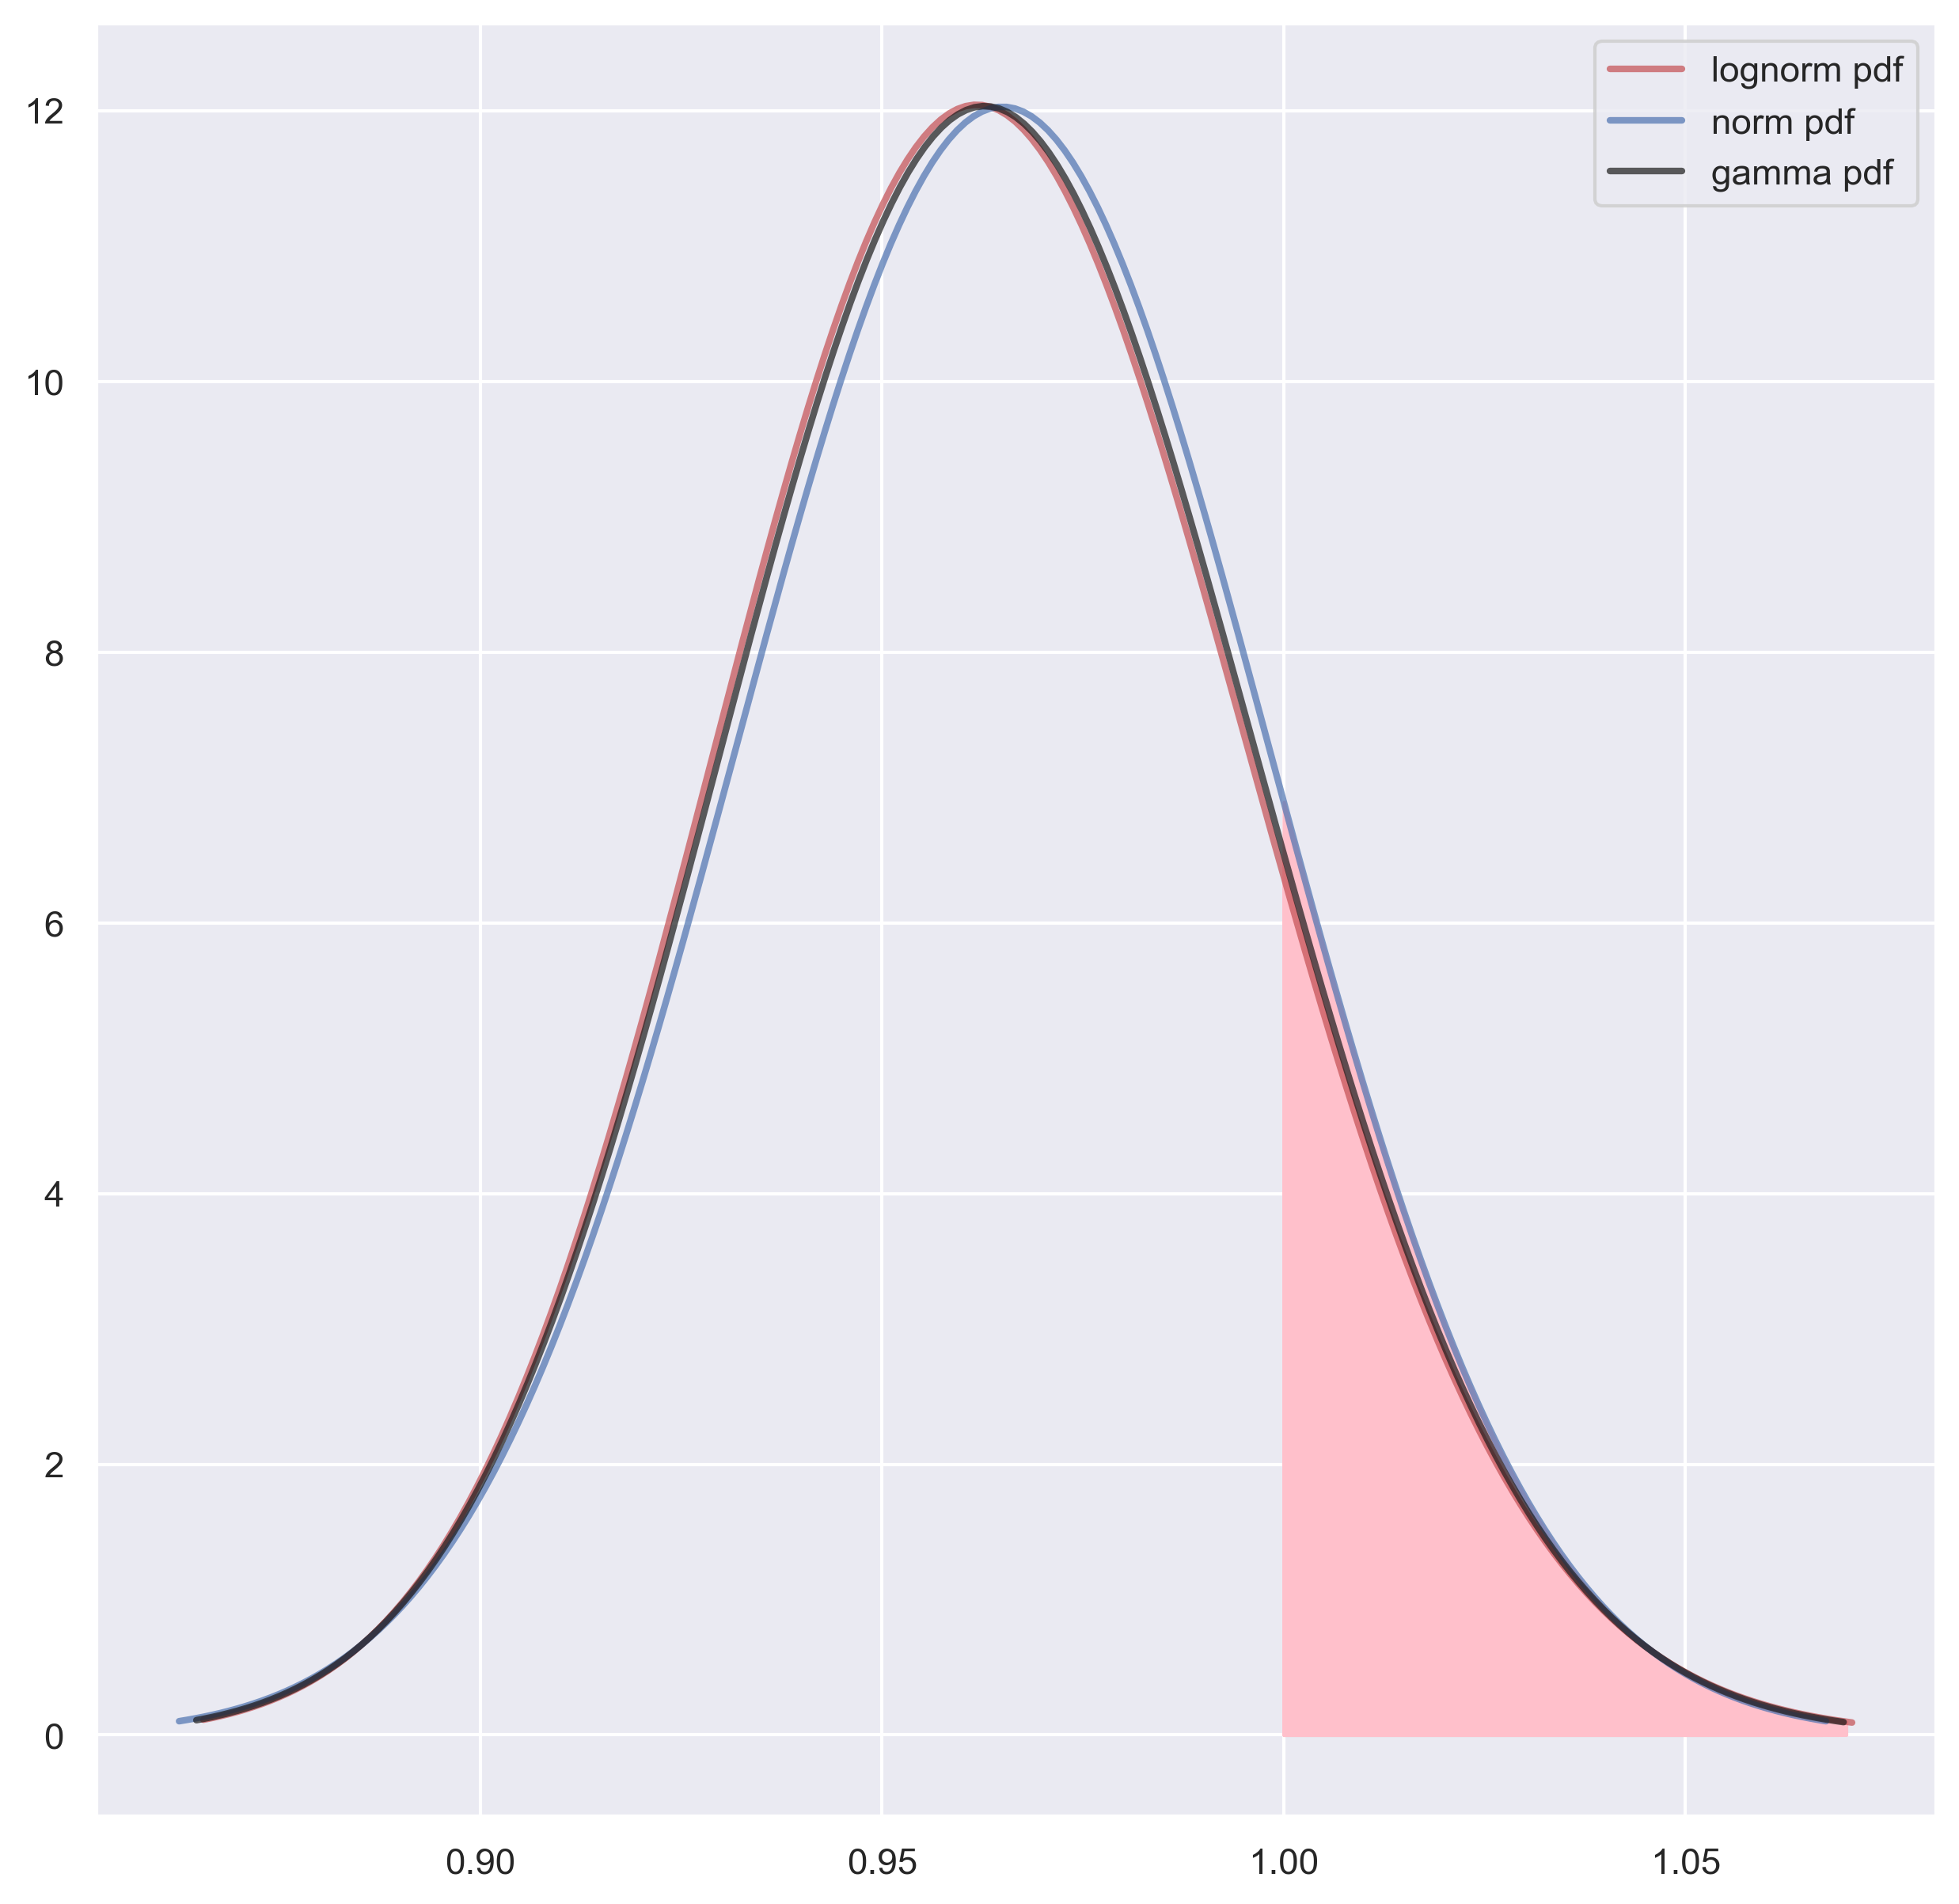

In [18]:
main(0.9, 1.03, 'Saturated fat', 'General mortality')
